<a href="https://colab.research.google.com/github/jahnavikrishnakancharla/-Lack-of-Access-to-Quality-Learning-Resources-/blob/main/Student_Mental_health.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install xgboost

In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [4]:
df = pd.read_csv("/content/archive (3).zip")

df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,8/7/2020 12:02,Female,18.0,Engineering,year 1,3.00 - 3.49,No,Yes,No,Yes,No
1,8/7/2020 12:04,Male,21.0,Islamic education,year 2,3.00 - 3.49,No,No,Yes,No,No
2,8/7/2020 12:05,Male,19.0,BIT,Year 1,3.00 - 3.49,No,Yes,Yes,Yes,No
3,8/7/2020 12:06,Female,22.0,Laws,year 3,3.00 - 3.49,Yes,Yes,No,No,No
4,8/7/2020 12:13,Male,23.0,Mathemathics,year 4,3.00 - 3.49,No,No,No,No,No


In [5]:
df.info()

print(df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 101 entries, 0 to 100
Data columns (total 11 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Timestamp                                     101 non-null    object 
 1   Choose your gender                            101 non-null    object 
 2   Age                                           100 non-null    float64
 3   What is your course?                          101 non-null    object 
 4   Your current year of Study                    101 non-null    object 
 5   What is your CGPA?                            101 non-null    object 
 6   Marital status                                101 non-null    object 
 7   Do you have Depression?                       101 non-null    object 
 8   Do you have Anxiety?                          101 non-null    object 
 9   Do you have Panic attack?                     101 non-null    obj

In [6]:
df = df.dropna()

print(df.isnull().sum())

Timestamp                                       0
Choose your gender                              0
Age                                             0
What is your course?                            0
Your current year of Study                      0
What is your CGPA?                              0
Marital status                                  0
Do you have Depression?                         0
Do you have Anxiety?                            0
Do you have Panic attack?                       0
Did you seek any specialist for a treatment?    0
dtype: int64


In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == "object":
        df[col] = le.fit_transform(df[col])

df.head()

,Timestamp,Choose your gender,Age,What is your course?,Your current year of Study,What is your CGPA?,Marital status,Do you have Depression?,Do you have Anxiety?,Do you have Panic attack?,Did you seek any specialist for a treatment?
0,23,0,18.0,17,3,3,0,1,0,1,0
1,24,1,21.0,25,4,3,0,0,1,0,0
2,25,1,19.0,4,0,3,0,1,1,1,0
3,26,0,22.0,33,5,3,1,1,0,0,0
4,27,1,23.0,37,6,3,0,0,0,0,0


In [8]:
print(df.columns)

Index(['Timestamp', 'Choose your gender', 'Age', 'What is your course?',
       'Your current year of Study', 'What is your CGPA?', 'Marital status',
       'Do you have Depression?', 'Do you have Anxiety?',
       'Do you have Panic attack?',
       'Did you seek any specialist for a treatment?'],
      dtype='object')


In [10]:
target = 'Do you have Depression?'
X = df.drop(target, axis=1)
y = df[target]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [12]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

In [13]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

In [14]:
svm = SVC()

svm.fit(X_train, y_train)

pred_svm = svm.predict(X_test)

In [15]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

In [16]:
mlp = MLPClassifier(max_iter=1000)

mlp.fit(X_train, y_train)

pred_mlp = mlp.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [17]:
xgb = XGBClassifier()

xgb.fit(X_train, y_train)

pred_xgb = xgb.predict(X_test)

In [18]:
def evaluate(y_true, y_pred, model_name):

    print(f"\n{model_name}")

    print("Accuracy :", accuracy_score(y_true, y_pred))

    print("Precision :", precision_score(y_true, y_pred, average='weighted'))

    print("Recall :", recall_score(y_true, y_pred, average='weighted'))

    print("F1 Score :", f1_score(y_true, y_pred, average='weighted'))

    print("Confusion Matrix")

    print(confusion_matrix(y_true, y_pred))

In [19]:
evaluate(y_test, pred_lr, "Logistic Regression")

evaluate(y_test, pred_rf, "Random Forest")

evaluate(y_test, pred_svm, "SVM")

evaluate(y_test, pred_knn, "KNN")

evaluate(y_test, pred_mlp, "MLP")

evaluate(y_test, pred_xgb, "XGBoost")


Logistic Regression
Accuracy : 0.8
Precision : 0.784313725490196
Recall : 0.8
F1 Score : 0.78125
Confusion Matrix
[[14  1]
 [ 3  2]]

Random Forest
Accuracy : 0.8
Precision : 0.784313725490196
Recall : 0.8
F1 Score : 0.78125
Confusion Matrix
[[14  1]
 [ 3  2]]

SVM
Accuracy : 0.75
Precision : 0.5625
Recall : 0.75
F1 Score : 0.6428571428571428
Confusion Matrix
[[15  0]
 [ 5  0]]

KNN
Accuracy : 0.6
Precision : 0.6
Recall : 0.6
F1 Score : 0.6
Confusion Matrix
[[11  4]
 [ 4  1]]

MLP
Accuracy : 0.75
Precision : 0.7678571428571428
Recall : 0.75
F1 Score : 0.7570532915360502
Confusion Matrix
[[12  3]
 [ 2  3]]

XGBoost
Accuracy : 0.7
Precision : 0.7
Recall : 0.7
F1 Score : 0.7
Confusion Matrix
[[12  3]
 [ 3  2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [20]:
models = {
    "Logistic Regression": pred_lr,
    "Random Forest": pred_rf,
    "SVM": pred_svm,
    "KNN": pred_knn,
    "MLP": pred_mlp,
    "XGBoost": pred_xgb
}

best_model = None
best_score = 0

for name, pred in models.items():

    score = accuracy_score(y_test, pred)

    print(name, ":", score)

    if score > best_score:
        best_score = score
        best_model = name

print("\nBest Model:", best_model)
print("Best Accuracy:", best_score)

Logistic Regression : 0.8
Random Forest : 0.8
SVM : 0.75
KNN : 0.6
MLP : 0.75
XGBoost : 0.7

Best Model: Logistic Regression
Best Accuracy: 0.8


In [21]:
evaluate(y_test, pred_lr, "Logistic Regression")

evaluate(y_test, pred_rf, "Random Forest")

evaluate(y_test, pred_svm, "SVM")

evaluate(y_test, pred_knn, "KNN")

evaluate(y_test, pred_mlp, "MLP")

evaluate(y_test, pred_xgb, "XGBoost")


Logistic Regression
Accuracy : 0.8
Precision : 0.784313725490196
Recall : 0.8
F1 Score : 0.78125
Confusion Matrix
[[14  1]
 [ 3  2]]

Random Forest
Accuracy : 0.8
Precision : 0.784313725490196
Recall : 0.8
F1 Score : 0.78125
Confusion Matrix
[[14  1]
 [ 3  2]]

SVM
Accuracy : 0.75
Precision : 0.5625
Recall : 0.75
F1 Score : 0.6428571428571428
Confusion Matrix
[[15  0]
 [ 5  0]]

KNN
Accuracy : 0.6
Precision : 0.6
Recall : 0.6
F1 Score : 0.6
Confusion Matrix
[[11  4]
 [ 4  1]]

MLP
Accuracy : 0.75
Precision : 0.7678571428571428
Recall : 0.75
F1 Score : 0.7570532915360502
Confusion Matrix
[[12  3]
 [ 2  3]]

XGBoost
Accuracy : 0.7
Precision : 0.7
Recall : 0.7
F1 Score : 0.7
Confusion Matrix
[[12  3]
 [ 3  2]]


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


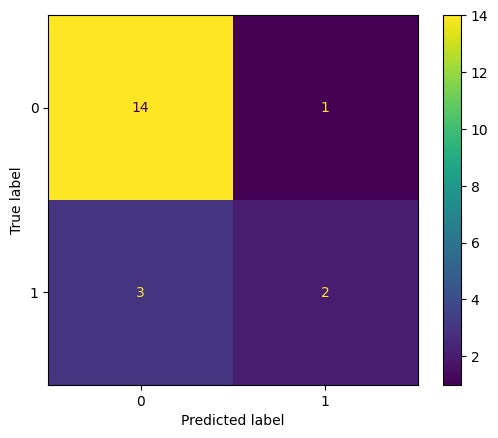

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred_lr
)

plt.show()

In [23]:
import joblib

joblib.dump(lr, "student_mental_health_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!
